## Preliminaries

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd

In [2]:
def plot_metric_vs_scheduling_all(
    data, size=(14, 16), image_path=""
):
    """Plots 'awt' vs metric_x1 and 'asd' vs metric_x2 side-by-side."""
    # Create a 1x2 grid of subplots
    fig, axes = plt.subplots(
        nrows=4, ncols=2, figsize=size, sharex=False, sharey=False
    )
    flat_axes = axes.flatten()

    # Define pairs: (y_axis_metric, x_axis_metric)
    plot_pairs = [("AWT", "ID"), ("ASD", "ID"), 
                  ("AWT", "QDS_AWT"), ("ASD", "QDS_ASD"), 
                  ("AWT", "OD_AWT"), ("ASD", "OD_AWT"),
                  ("AWT", "OD_ASD"), ("ASD", "OD_ASD")]

    for j, (sched_metric, metric_col) in enumerate(plot_pairs):
        ax = flat_axes[j]

        # Show legend only for the last column (the second plot)
        show_legend = j == len(plot_pairs) - 1

        sns.scatterplot(
            data=data,
            x=metric_col,
            y=sched_metric,
            hue="Estimation",
            s=100,  # Slightly larger points since there are fewer subplots
            ax=ax,
            legend=show_legend,
        )

        ax.set_title(f"{sched_metric.upper()} vs {metric_col}")
        ax.set_xlabel("Normalized Metric Value")
        ax.set_ylabel(sched_metric.upper())
        ax.grid(True)

        # Cleanly position the legend on the far right of the entire figure
        if show_legend:
            handles, labels = ax.get_legend_handles_labels()
            ax.legend(
                handles=handles,
                labels=labels,
                loc="center left",
                bbox_to_anchor=(1.05, 0.5),
                borderaxespad=0.0,
            )

    plt.tight_layout()

    # Adjust to make sure the legend doesn't get cut off
    plt.subplots_adjust(right=0.85)

    if image_path:
        plt.savefig(image_path, dpi=300, bbox_inches="tight")
        print(f"Grafico salvato in: {image_path}")

    plt.show()

In [3]:
def plot_metric_vs_scheduling(
    data, size=(14, 4), image_path=""
):
    """Plots 'awt' vs metric_x1 and 'asd' vs metric_x2 side-by-side."""
    # Create a 1x2 grid of subplots
    fig, axes = plt.subplots(
        nrows=1, ncols=2, figsize=size, sharex=False, sharey=False
    )
    flat_axes = axes.flatten()

    # Define pairs: (y_axis_metric, x_axis_metric)
    plot_pairs = [("AWT", "OD_AWT"), ("ASD", "OD_ASD")]

    for j, (sched_metric, metric_col) in enumerate(plot_pairs):
        ax = flat_axes[j]

        # Show legend only for the last column (the second plot)
        show_legend = j == len(plot_pairs) - 1

        sns.scatterplot(
            data=data,
            x=metric_col,
            y=sched_metric,
            hue="Estimation",
            s=100,  # Slightly larger points since there are fewer subplots
            ax=ax,
            legend=show_legend,
        )

        ax.set_title(f"{sched_metric.upper()} vs {metric_col}")
        ax.set_xlabel("Normalized Metric Value")
        ax.set_ylabel(sched_metric.upper())
        ax.grid(True)

        # Cleanly position the legend on the far right of the entire figure
        if show_legend:
            handles, labels = ax.get_legend_handles_labels()
            ax.legend(
                handles=handles,
                labels=labels,
                loc="center left",
                bbox_to_anchor=(1.05, 0.5),
                borderaxespad=0.0,
            )

    plt.tight_layout()

    # Adjust to make sure the legend doesn't get cut off
    plt.subplots_adjust(right=0.85)

    if image_path:
        plt.savefig(image_path, dpi=300, bbox_inches="tight")
        print(f"Grafico salvato in: {image_path}")

    plt.show()

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot_metric_vs_scheduling(data, size=(14, 4), image_path=""):
    """Plots 'awt' vs metric_x1 and 'asd' vs metric_x2 side-by-side."""
    # Create a 1x2 grid of subplots
    fig, axes = plt.subplots(
        nrows=1, ncols=2, figsize=size, sharex=False, sharey=False
    )
    flat_axes = axes.flatten()

    # Definizione coppie: (y_metric, x_column_name, x_label_latex)
    plot_pairs = [
        ("AWT", "OD_AWT", r"$\text{OD}_{\text{AWT}}$"),
        ("ASD", "OD_ASD", r"$\text{OD}_{\text{ASD}}$"),
    ]

    for j, (sched_metric, metric_col, latex_label) in enumerate(plot_pairs):
        ax = flat_axes[j]

        # Show legend only for the last column (the second plot)
        show_legend = j == len(plot_pairs) - 1

        sns.scatterplot(
            data=data,
            x=metric_col,
            y=sched_metric,
            hue="Estimation",
            s=100,  # Slightly larger points since there are fewer subplots
            ax=ax,
            legend=show_legend,
        )

        # Utilizzo della stringa LaTeX per titolo e asse X
        ax.set_title(f"{sched_metric.upper()} vs {latex_label}")
        ax.set_xlabel(f"Normalized {latex_label} Value")
        ax.set_ylabel(sched_metric.upper())
        ax.grid(True)

        # Cleanly position the legend on the far right of the entire figure
        if show_legend:
            handles, labels = ax.get_legend_handles_labels()
            ax.legend(
                handles=handles,
                labels=labels,
                loc="center left",
                bbox_to_anchor=(1.05, 0.5),
                borderaxespad=0.0,
            )

    plt.tight_layout()

    # Adjust to make sure the legend doesn't get cut off
    plt.subplots_adjust(right=0.85)

    if image_path:
        plt.savefig(image_path, dpi=300, bbox_inches="tight")
        print(f"Grafico salvato in: {image_path}")

    plt.show()

## PM100

### Correlation and Ablation Study

In [14]:
df = pd.DataFrame(
    {
        "Estimation": ["1 - User", "2 - Actual", "3 - Heuristic", "4 - DT", "5 - RNP", "6 - KNN", "7 - LLM"],
        "AWT": [1192.11, 416.00, 815.37, 616.15, 796.35, 702.35, 434.19],
        "ASD": [649.98, 1.28, 247.64, 8.82, 93.97, 216.00, 3.36],
        "ID": [273864.38571783976, 0, 195246.21276698523, 85974.1427945924, 95929.21531127646, 157499.10222584032, 10143.50735678133],
        "ID_H": [4576337.199656702, 0, 5053369.052217598, 4836070.295518545, 4516041.618113932, 2480766.5414839364, 244311.40537288107],
        "ID_P": [2941301.1440066015, 0, 2150880.7629920803, 807519.1226232967, 999366.910529383, 1763896.7406368633, 101030.72382874548],
        "ID_AWT": [49890999.72077808, 0, 54096817.25029537, 45359048.106447026, 47653581.219136424, 27130931.21163154, 2403596.9203109797],
        "ID_ASD": [265490.2746352209, 0, 168811.41564270365, 56015.83433810435, 70586.08022961816, 144640.09847008323, 7790.951828418098],
        "QDS_AWT": [273.00375705837894, 0, 166.62085410821103, 83.32297583903282, 145.57673740592583, 184.37167874396133, 64.53242407738523],
        "QDS_ASD": [702.3525276777378, 0, 280.8931387391752, 70.11915305205642, 190.21002214839424, 347.68591023365866, 16.144317364407996],
        "OD_AWT": [13670321366.891727, 0, 9067754712.030313, 3824809917.56146, 6984906460.809319, 5029306264.587075, 157513532.69291624],
        "OD_AWT_B": [75039870.61117315, 0, 32727336.945395563, 7249595.565649972, 14060991.40223749, 29195872.980270796, 664728.625736671],
        "OD_ASD": [192623207.93555355, 0, 55038567.743822284, 6114408.21992797, 18342627.384347253, 54917717.82060119, 173903.50931286643],
        "OD_ASD_B": [186733255.73853943, 0, 47586779.81052523, 3983798.6956302808, 13496765.964073623, 50433964.39132699, 133570.55071721462],
        
    }
)

df.ID = df.ID/max(df.ID)
df.ID_H = df.ID_H/max(df.ID_H)
df.ID_P = df.ID_P/max(df.ID_P)
df.ID_AWT = df.ID_AWT/max(df.ID_AWT)
df.ID_ASD = df.ID_ASD/max(df.ID_ASD)
df.QDS_AWT = df.QDS_AWT/max(df.QDS_AWT)
df.QDS_ASD = df.QDS_ASD/max(df.QDS_ASD)
df.OD_AWT = df.OD_AWT/max(df.OD_AWT)
df.OD_ASD = df.OD_ASD/max(df.OD_ASD)
df.OD_AWT_B = df.OD_AWT_B/max(df.OD_AWT_B)
df.OD_ASD_B = df.OD_ASD_B/max(df.OD_ASD_B)

df

,Estimation,AWT,ASD,ID,ID_H,ID_P,ID_AWT,ID_ASD,QDS_AWT,QDS_ASD,OD_AWT,OD_AWT_B,OD_ASD,OD_ASD_B
0,1 - User,1192.11,649.98,1.000000,0.905601,1.000000,0.922254,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,2 - Actual,416.00,1.28,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,3 - Heuristic,815.37,247.64,0.712930,1.000000,0.731268,1.000000,0.635848,0.610324,0.399932,0.663317,0.436133,0.285732,0.254838
3,4 - DT,616.15,8.82,0.313930,0.956999,0.274545,0.838479,0.210990,0.305208,0.099835,0.279789,0.096610,0.031743,0.021334
4,5 - RNP,796.35,93.97,0.350280,0.893669,0.339770,0.880894,0.265871,0.533241,0.270818,0.510954,0.187380,0.095225,0.072278
5,6 - KNN,702.35,216.00,0.575099,0.490913,0.599699,0.501525,0.544804,0.675345,0.495030,0.367900,0.389071,0.285104,0.270086
6,7 - LLM,434.19,3.36,0.037038,0.048346,0.034349,0.044431,0.029346,0.236379,0.022986,0.011522,0.008858,0.000903,0.000715


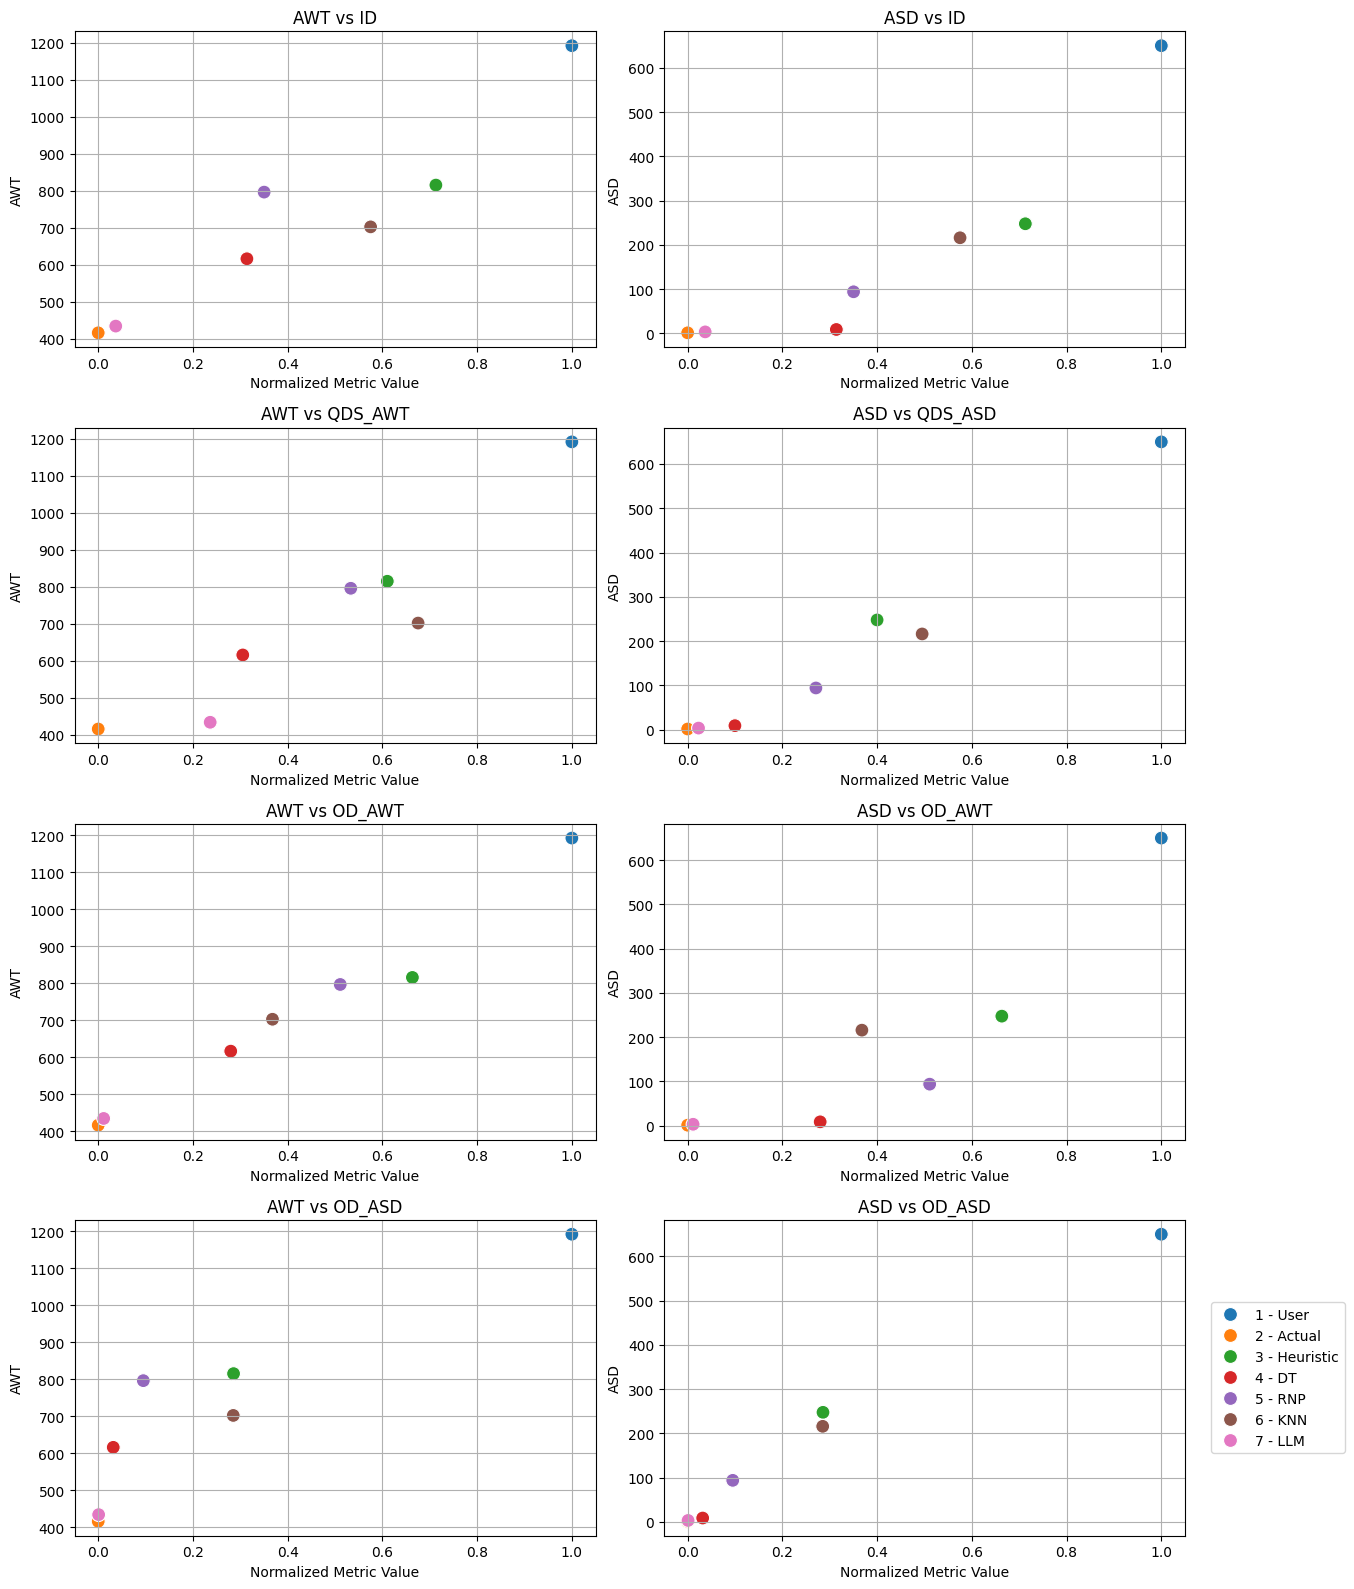

In [15]:
plot_metric_vs_scheduling_all(data=df)
# plot_metric_vs_scheduling(data=df, image_path="images/1800x980/scatter_plots_ASDched_aware_M2.png")

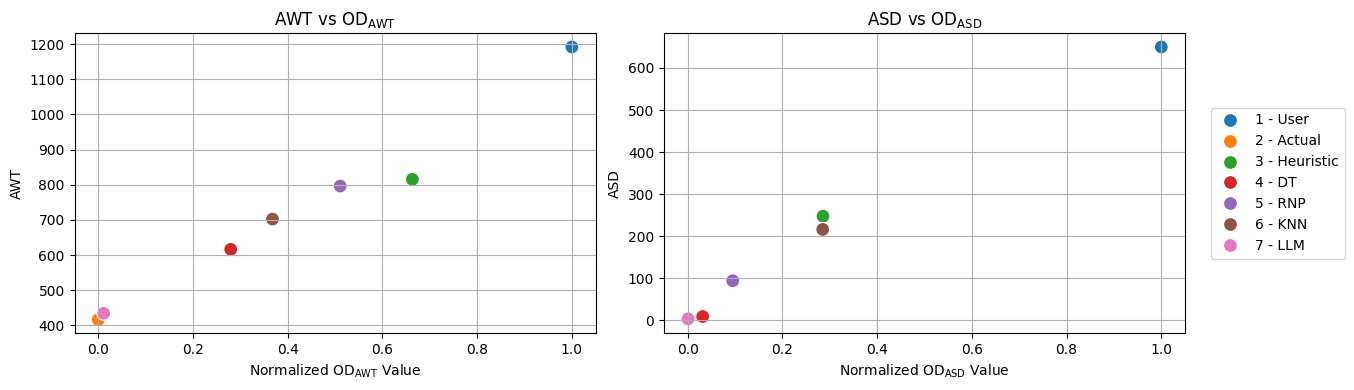

In [16]:
plot_metric_vs_scheduling(data=df)
# plot_metric_vs_scheduling(data=df, image_path="images/1800x980/scatter_plots_sched_aware_M2.png")

In [17]:
corr_cols = [
    "AWT", "ASD",
    "OD_AWT", "OD_ASD"
]

corr = df[corr_cols].corr()

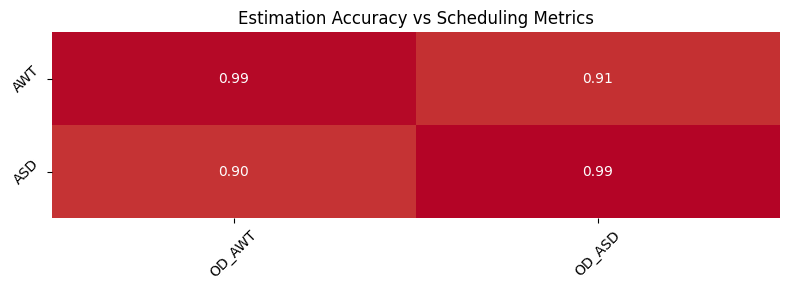

In [18]:
plt.figure(figsize=(8, 3))
sns.heatmap(corr.iloc[0:2, -2:], annot=True, cmap="coolwarm", fmt=".2f", cbar=False, vmin=-1, vmax=1)
plt.tick_params(axis='x', labelrotation=45)
plt.tick_params(axis='y', labelrotation=45)
plt.title("Estimation Accuracy vs Scheduling Metrics")
plt.tight_layout()
# plt.savefig("images/1800x980/correlation_ASDched_aware_M2.png", dpi=300)
plt.show()

In [19]:
corr_cols = [
    "AWT", "ASD",
    "ID", "ID_H", "ID_P", "ID_AWT", "ID_ASD", "QDS_AWT", "QDS_ASD", "OD_AWT_B", "OD_AWT", "OD_ASD_B", "OD_ASD"
]

corr = df[corr_cols].corr()

In [20]:
corr.iloc[0:2, -11:]

,ID,ID_H,ID_P,ID_AWT,ID_ASD,QDS_AWT,QDS_ASD,OD_AWT_B,OD_AWT,OD_ASD_B,OD_ASD
AWT,0.941798,0.735325,0.931593,0.785141,0.935627,0.940431,0.942839,0.942897,0.988339,0.895502,0.907502
ASD,0.918854,0.467781,0.919864,0.531527,0.954444,0.900617,0.982693,0.995671,0.898822,0.989954,0.993854


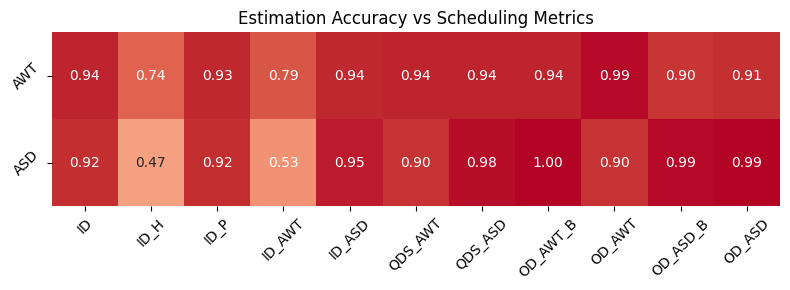

In [21]:
plt.figure(figsize=(8, 3))
sns.heatmap(corr.iloc[0:2, -11:], annot=True, cmap="coolwarm", fmt=".2f", cbar=False, vmin=-1, vmax=1)
plt.tick_params(axis='x', labelrotation=45)
plt.tick_params(axis='y', labelrotation=45)
plt.title("Estimation Accuracy vs Scheduling Metrics")
plt.tight_layout()
# plt.savefig("images/1800x980/correlation_ASDched_aware_M2.png", dpi=300)
plt.show()

## F-DATA

### Correlation and Ablation Study

In [25]:
df = pd.DataFrame(
    {
        "Estimation": ["1 - User", "2 - Actual", "3 - Heuristic", "4 - DT", "5 - RNP", "6 - KNN", "7 - LLM"],
        "AWT": [6564.22, 5322.34, 6968.10, 8898.37, 10672.49, 5644.64, 5510.67],
        "ASD": [60.95, 1.73, 70.34, 16.23, 83.55, 39.62, 19.40],
        "ID": [4285719.865245825, 0, 4540166.691992608, 5370743.714357964, 6683661.249775931, 2691150.6641872637, 1098111.716212449],
        "ID_H": [13096053.772707932, 0, 14261512.147071382, 23904045.198112324, 24071934.31515471, 10418465.113217726, 3161346.000683481],
        "ID_P": [67078654.907227844, 0, 71964402.11360256, 85766281.78922702, 107952631.48931381, 42842739.192744136, 16946969.07272175],
        "ID_AWT": [200650058.6612031, 0, 222388702.70052177, 380514306.1635782, 390043573.01189595, 164566226.0103142, 47837563.354174145],
        "ID_ASD": [2683031.057756298, 0, 2632164.56262636, 2319302.9943053797, 4220420.8382853065, 1434167.447651761, 570717.6861325346],
        "QDS_AWT": [1409.4364194153864, 0, 1327.373059941865, 1448.5140839698893, 1629.9730081277864, 1250.859007882153, 1052.3859088097101],
        "QDS_ASD": [804.8702113164295, 0, 736.5203244682393, 373.67552242557986, 812.3270220913445, 348.14878887890626, 173.09745083771537],
        "OD_AWT": [283004150293.5945, 0, 295415161502.7938, 551560845936.1371, 636150539576.1218, 206013712424.1821, 50391415149.07882],
        "OD_AWT_B": [6044735381.354713, 0, 6031035121.288356, 7784968655.354625, 10900871093.854172, 3368941200.530865, 1156735408.157041],
        "OD_ASD": [2162174805.4826117, 0, 1941274862.2819943, 868986061.0545799, 3432582312.374844, 500737827.3971645, 99360494.30367362],
        "OD_ASD_B": [3453733973.4486723, 0, 3348465211.818281, 2012286206.9909694, 5436002300.947572, 939611995.0916473, 191178450.52761608]
     }
)

df.ID = df.ID/max(df.ID)
df.ID_H = df.ID_H/max(df.ID_H)
df.ID_P = df.ID_P/max(df.ID_P)
df.ID_AWT = df.ID_AWT/max(df.ID_AWT)
df.ID_ASD = df.ID_ASD/max(df.ID_ASD)
df.QDS_AWT = df.QDS_AWT/max(df.QDS_AWT)
df.QDS_ASD = df.QDS_ASD/max(df.QDS_ASD)
df.OD_AWT = df.OD_AWT/max(df.OD_AWT)
df.OD_ASD = df.OD_ASD/max(df.OD_ASD)
df.OD_AWT_B = df.OD_AWT_B/max(df.OD_AWT_B)
df.OD_ASD_B = df.OD_ASD_B/max(df.OD_ASD_B)

df

,Estimation,AWT,ASD,ID,ID_H,ID_P,ID_AWT,ID_ASD,QDS_AWT,QDS_ASD,OD_AWT,OD_AWT_B,OD_ASD,OD_ASD_B
0,1 - User,6564.22,60.95,0.641223,0.544038,0.621371,0.514430,0.635726,0.864699,0.990820,0.444870,0.554519,0.629897,0.635344
1,2 - Actual,5322.34,1.73,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,3 - Heuristic,6968.10,70.34,0.679293,0.592454,0.666629,0.570164,0.623673,0.814353,0.906680,0.464379,0.553262,0.565544,0.615979
3,4 - DT,8898.37,16.23,0.803563,0.993026,0.794481,0.975569,0.549543,0.888674,0.460006,0.867029,0.714160,0.253158,0.370178
4,5 - RNP,10672.49,83.55,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,6 - KNN,5644.64,39.62,0.402646,0.432805,0.396866,0.421918,0.339816,0.767411,0.428582,0.323844,0.309052,0.145878,0.172850
6,7 - LLM,5510.67,19.40,0.164298,0.131329,0.156985,0.122647,0.135228,0.645646,0.213088,0.079213,0.106114,0.028946,0.035169


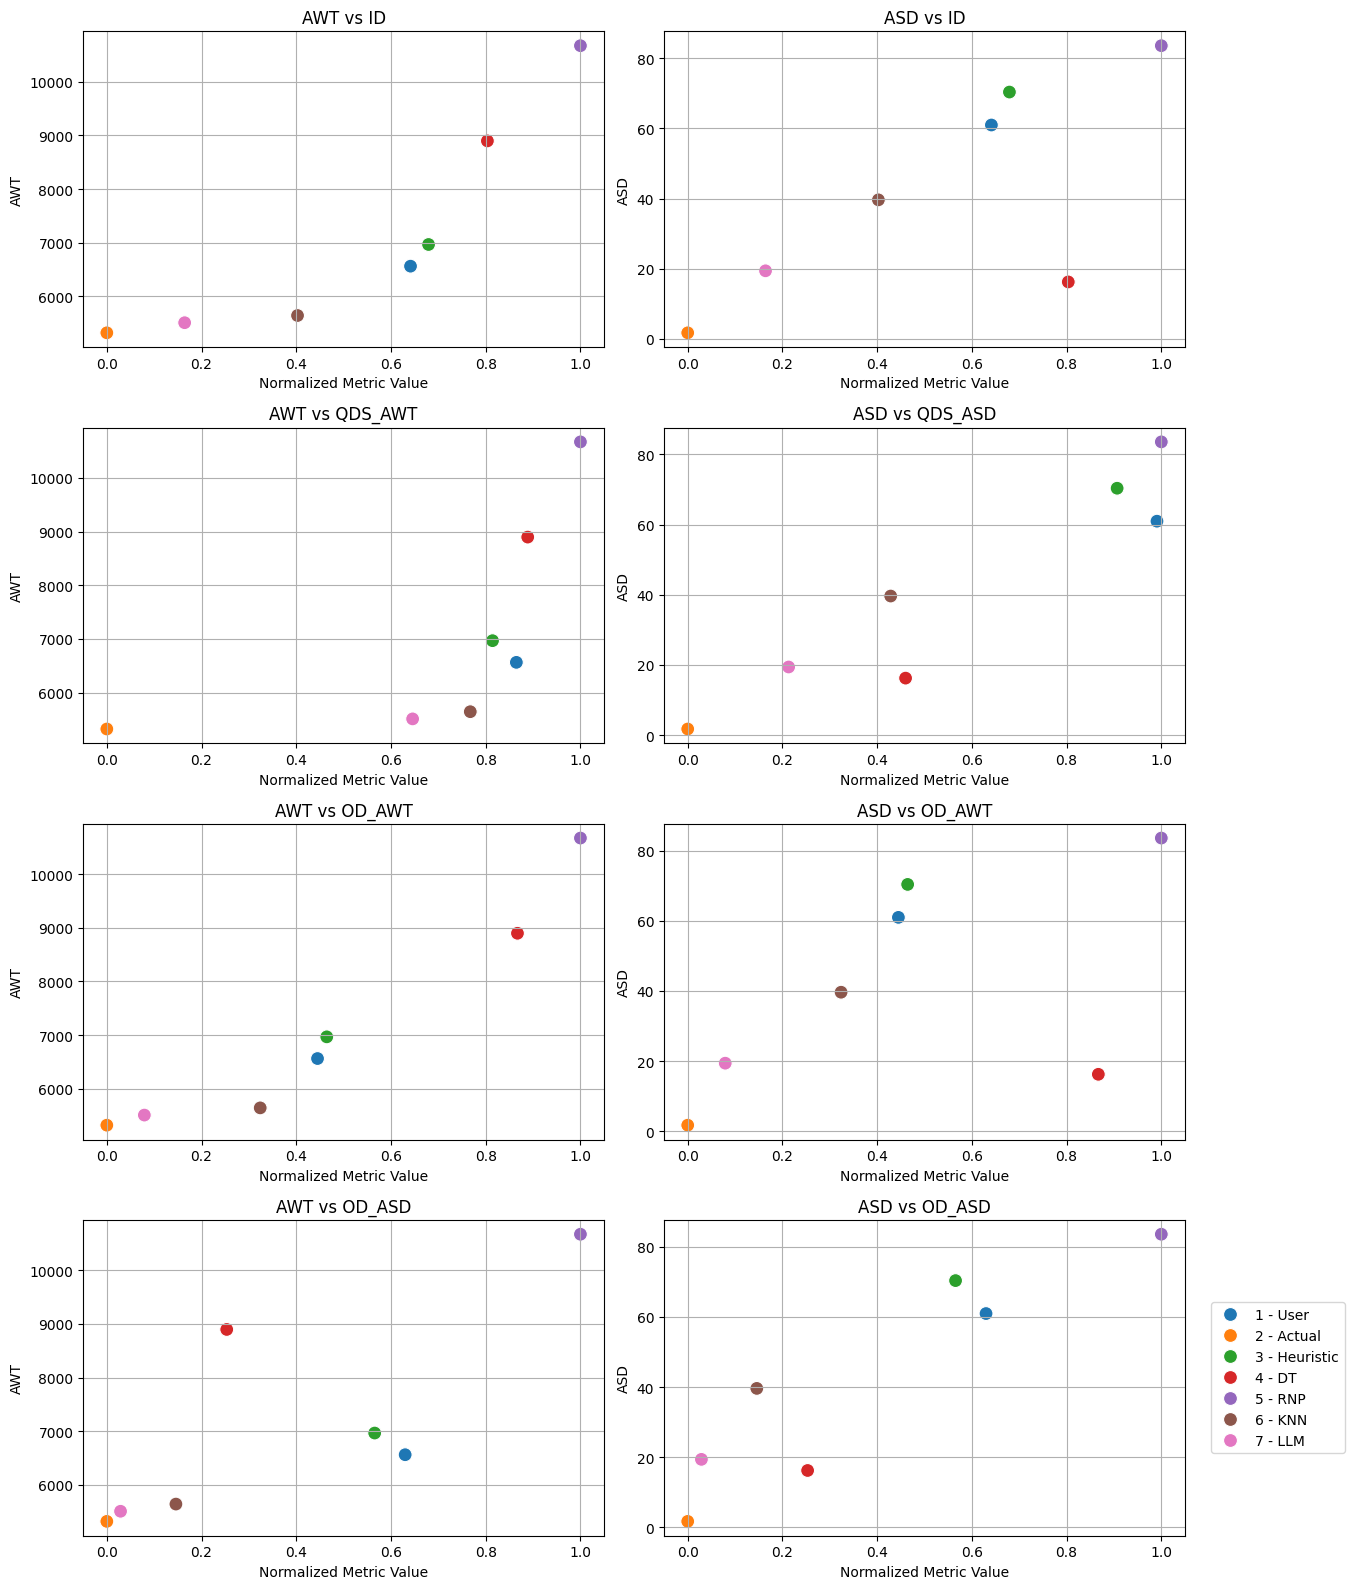

In [26]:
plot_metric_vs_scheduling_all(data=df)

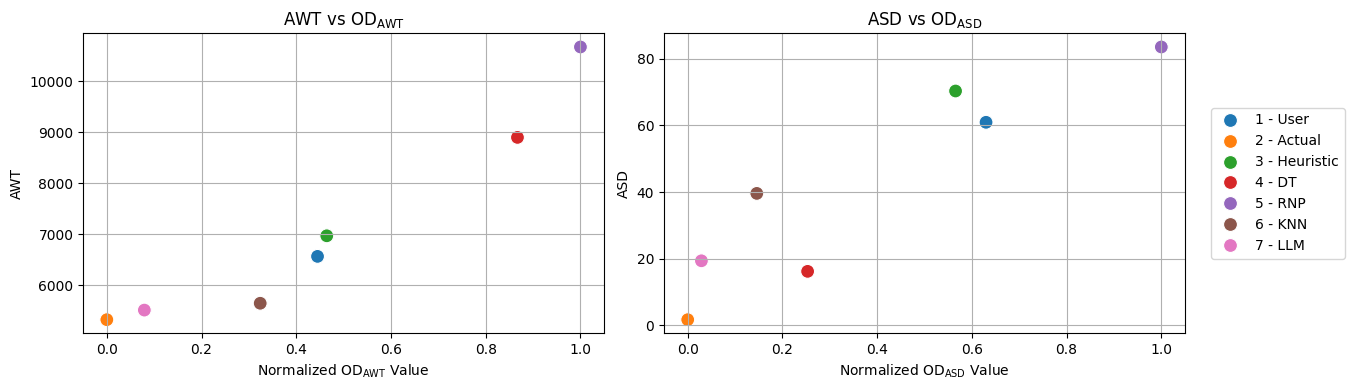

In [27]:
# plot_metric_vs_scheduling(data=df, image_path="images/18000x158976/scatter_plots_sched_aware_F2.png") 
plot_metric_vs_scheduling(data=df)

In [28]:
corr_cols = [
    "AWT", "ASD", # "ASU",
    "OD_AWT", "OD_ASD"
]

corr = df[corr_cols].corr()

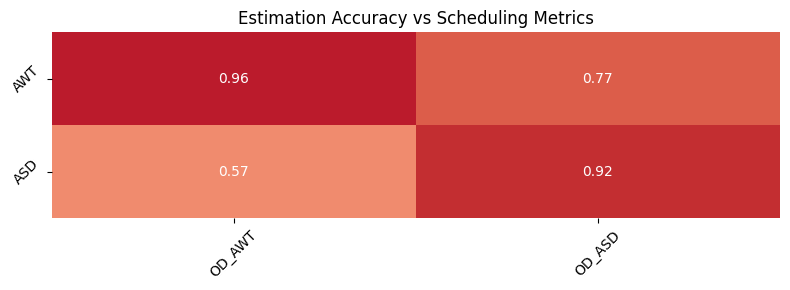

In [29]:
plt.figure(figsize=(8, 3))
sns.heatmap(corr.iloc[0:2, -2:], annot=True, cmap="coolwarm", fmt=".2f", cbar=False, vmin=-1, vmax=1)
plt.tick_params(axis='x', labelrotation=45)
plt.tick_params(axis='y', labelrotation=45)
plt.title("Estimation Accuracy vs Scheduling Metrics")
plt.tight_layout()
# plt.savefig("images/1800x980/correlation_ASDched_aware_M2.png", dpi=300)
plt.show()

In [30]:
corr_cols = [
    "AWT", "ASD",
    "ID", "ID_H", "ID_P", "ID_AWT", "ID_ASD", "QDS_AWT", "QDS_ASD", "OD_AWT_B", "OD_AWT", "OD_ASD_B", "OD_ASD"
]

corr = df[corr_cols].corr()

In [31]:
corr.iloc[0:2, -11:]

,ID,ID_H,ID_P,ID_AWT,ID_ASD,QDS_AWT,QDS_ASD,OD_AWT_B,OD_AWT,OD_ASD_B,OD_ASD
AWT,0.887183,0.910303,0.894439,0.919062,0.855492,0.636127,0.593598,0.933153,0.957525,0.806320,0.765406
ASD,0.740317,0.565492,0.738249,0.561076,0.867195,0.704437,0.941520,0.730770,0.569963,0.902592,0.919665


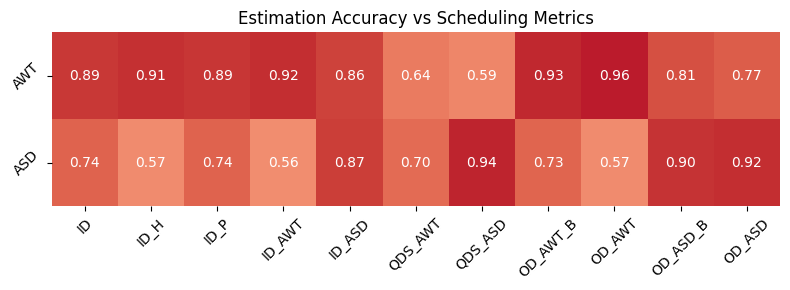

In [32]:
plt.figure(figsize=(8, 3))
sns.heatmap(corr.iloc[0:2, -11:], annot=True, cmap="coolwarm", fmt=".2f", cbar=False, vmin=-1, vmax=1)
plt.tick_params(axis='x', labelrotation=45)
plt.tick_params(axis='y', labelrotation=45)
plt.title("Estimation Accuracy vs Scheduling Metrics")
plt.tight_layout()
# plt.savefig("images/1800x980/correlation_ASDched_aware_M2.png", dpi=300)
plt.show()

## Statistical Significance

In [21]:
import numpy as np
from scipy.stats import spearmanr, wilcoxon

In [22]:
df = pd.DataFrame(
    {
        "Estimation": ["1 - User", "2 - Actual", "3 - Heuristic", "4 - DT", "5 - RNP", "6 - KNN", "7 - LLM"],
        "AWT_M1": [1192.11, 416.00, 815.37, 616.15, 796.35, 702.35, 434.19],
        "ASD_M1": [649.98, 1.28, 247.64, 8.82, 93.97, 216.00, 3.36],
        "AWT_M2": [1551.79, 488.19, 1019.64, 567.12, 831.08, 860.54, 516.78],
        "ASD_M2": [862.35, 1.33, 341.72, 7.86, 116.75, 268.44, 4.95],
        "AWT_M3": [2501.05, 689.93, 1372.62, 886.53, 1722.73, 1370.98, 700.79],
        "ASD_M3": [1332.74, 1.70, 416.16, 13.17, 165.32, 421.71, 3.85],
        "AWT_M4": [1638.79, 519.45, 1026.04, 677.93, 834.10, 918.52, 551.97],
        "ASD_M4": [877.89, 1.36, 311.12, 8.79, 113.34, 275.54, 12.26],
        "AWT_M5": [2003.55, 611.22, 1214.01, 835.17, 1325.38, 1119.87, 659.84],
        "ASD_M5": [1091.24, 1.46, 346.46, 13.04, 142.90, 335.11, 7.51],
        "AWT_F1": [6564.22, 5322.34, 6968.10, 8898.37, 10672.49, 5644.64, 5510.67],
        "ASD_F1": [60.95, 1.73, 70.34, 16.23, 83.55, 39.62, 19.40],
        "AWT_F2": [6029.04, 4961.21, 6198.26, 8354.93, 8249.41, 5608.46, 5128.05],
        "ASD_F2": [46.85, 1.69, 53.30, 18.45, 40.88, 32.48, 13.39],
        "AWT_F3": [7676.60, 6341.47, 8620.75, 11342.87, 12626.72, 6301.17, 6659.89],
        "ASD_F3": [76.15, 1.87, 84.78, 20.57, 109.36, 46.42, 22.09],
        "AWT_F4": [7378.81, 5688.63, 7177.85, 10175.88, 10929.03, 6391.66, 6102.05],
        "ASD_F4": [52.26, 2.13, 58.22, 23.71, 64.00, 34.24, 16.13],
        "AWT_F5": [8607.17, 7158.93, 8739.89, 11755.35, 14409.36, 7887.55, 7504.32],
        "ASD_F5": [73.30, 2.16, 81.54, 30.90, 107.23, 53.92, 24.39],
        "OD_AWT_M1": [13670321366.891727, 0, 9067754712.030313, 3824809917.56146, 6984906460.809319, 5029306264.587075, 157513532.69291624],
        "OD_ASD_M1": [186733255.73853943, 0, 47586779.81052523, 3983798.6956302808, 13496765.964073623, 50433964.39132699, 133570.55071721462],
        "OD_AWT_M2": [26727212199.002853, 0, 23528390416.125767, 4218729905.316532, 13371963397.938272, 7830224779.977585, 254743077.61697954],
        "OD_ASD_M2": [303220071.99183744, 0, 105875954.70081319, 2709974.5674777715, 15738779.623845167, 49906339.245127976, 187500.96041153243],
        "OD_AWT_M3": [51359755831.86006, 0, 27993467534.338783, 11882636368.776566, 39196178057.98525, 18926011988.693882, 584800570.4677511],
        "OD_ASD_M3": [289397395.5542306, 0, 112286626.52068493, 8834758.651098523, 31345951.598691855, 67634160.65412682, 220982.44210402694],
        "OD_AWT_M4": [37416624885.72896, 0, 19172413584.143166, 6596908195.771634, 6967640049.436681, 11056367210.171545, 166368205.80202526],
        "OD_ASD_M4": [352487460.40068793, 0, 64448289.07533162, 5398365.321287194, 11695000.541776784, 53748677.803142205, 118576.70104696388],
        "OD_AWT_M5": [36480936298.09854, 0, 19632388805.11136, 12580093882.551453, 32609105768.00629, 15367018062.557436, 816414121.7280858],
        "OD_ASD_M5": [264204191.04294497, 0, 71196716.75818971, 6580366.701678407, 27004054.32909537, 72322911.41773899, 380501.07551313605],
        "OD_AWT_F1": [283004150293.5945, 0, 295415161502.7938, 551560845936.1371, 636150539576.1218, 206013712424.1821, 50391415149.07882],
        "OD_ASD_F1": [2162174805.4826117, 0, 1941274862.2819943, 868986061.0545799, 3432582312.374844, 500737827.3971645, 99360494.30367362],
        "OD_AWT_F2": [294227860661.2166, 0, 371377188796.13116, 542074527365.93835, 659385529770.1708, 295366545028.0533, 53420255234.190926],
        "OD_ASD_F2": [1860221065.8055582, 0, 1763878046.5297408, 723529597.3914655, 2769303132.3301415, 458782864.03665674, 112174106.28752576],
        "OD_AWT_F3": [302871652471.52527, 0, 362855461528.12897, 645215989265.4724, 731497882897.2657, 171390080762.25293, 55684556602.91508],
        "OD_ASD_F3": [1973191172.8347588, 0, 2047120001.3807008, 993214132.7619069, 3601383743.0165854, 439385230.9084551, 132137600.29267566],
        "OD_AWT_F4": [321835998870.84784, 0, 355849530374.8574, 774377480726.4027, 740887030560.6981, 222856146510.30865, 80371471654.95036],
        "OD_ASD_F4": [2014679864.3514235, 0, 1852392985.7226155, 1366276317.8557684, 3321747978.3195868, 492369112.06712526, 170794820.07098946],
        "OD_AWT_F5": [301858160033.964, 0, 403409601682.4585, 699519327224.1111, 1047251423948.3341, 244555216515.20038, 61256876741.91601],
        "OD_ASD_F5": [2360844492.4526463, 0, 2299522504.6009984, 1196179463.6419253, 5253294079.699621, 630193907.542351, 169829232.4196639]
    }
)

df.OD_AWT_M1 = df.OD_AWT_M1/max(df.OD_AWT_M1)
df.OD_ASD_M1 = df.OD_ASD_M1/max(df.OD_ASD_M1)
df.OD_AWT_M2 = df.OD_AWT_M2/max(df.OD_AWT_M2)
df.OD_ASD_M2 = df.OD_ASD_M2/max(df.OD_ASD_M2)
df.OD_AWT_M3 = df.OD_AWT_M3/max(df.OD_AWT_M3)
df.OD_ASD_M3 = df.OD_ASD_M3/max(df.OD_ASD_M3)
df.OD_AWT_M4 = df.OD_AWT_M4/max(df.OD_AWT_M4)
df.OD_ASD_M4 = df.OD_ASD_M4/max(df.OD_ASD_M4)
df.OD_AWT_M5 = df.OD_AWT_M5/max(df.OD_AWT_M5)
df.OD_ASD_M5 = df.OD_ASD_M5/max(df.OD_ASD_M5)
df.OD_AWT_F1 = df.OD_AWT_F1/max(df.OD_AWT_F1)
df.OD_ASD_F1 = df.OD_ASD_F1/max(df.OD_ASD_F1)
df.OD_AWT_F2 = df.OD_AWT_F2/max(df.OD_AWT_F2)
df.OD_ASD_F2 = df.OD_ASD_F2/max(df.OD_ASD_F2)
df.OD_AWT_F3 = df.OD_AWT_F3/max(df.OD_AWT_F3)
df.OD_ASD_F3 = df.OD_ASD_F3/max(df.OD_ASD_F3)
df.OD_AWT_F4 = df.OD_AWT_F4/max(df.OD_AWT_F4)
df.OD_ASD_F4 = df.OD_ASD_F4/max(df.OD_ASD_F4)
df.OD_AWT_F5 = df.OD_AWT_F5/max(df.OD_AWT_F5)
df.OD_ASD_F5 = df.OD_ASD_F5/max(df.OD_ASD_F5)

df

,Estimation,AWT_M1,ASD_M1,AWT_M2,ASD_M2,AWT_M3,ASD_M3,AWT_M4,ASD_M4,AWT_M5,...,OD_AWT_F1,OD_ASD_F1,OD_AWT_F2,OD_ASD_F2,OD_AWT_F3,OD_ASD_F3,OD_AWT_F4,OD_ASD_F4,OD_AWT_F5,OD_ASD_F5
0,1 - User,1192.11,649.98,1551.79,862.35,2501.05,1332.74,1638.79,877.89,2003.55,...,0.444870,0.629897,0.446215,0.671729,0.414043,0.547898,0.415606,0.606512,0.288238,0.449403
1,2 - Actual,416.00,1.28,488.19,1.33,689.93,1.70,519.45,1.36,611.22,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,3 - Heuristic,815.37,247.64,1019.64,341.72,1372.62,416.16,1026.04,311.12,1214.01,...,0.464379,0.565544,0.563217,0.636939,0.496044,0.568426,0.459530,0.557656,0.385208,0.437730
3,4 - DT,616.15,8.82,567.12,7.86,886.53,13.17,677.93,8.79,835.17,...,0.867029,0.253158,0.822090,0.261268,0.882048,0.275787,1.000000,0.411312,0.667957,0.227701
4,5 - RNP,796.35,93.97,831.08,116.75,1722.73,165.32,834.10,113.34,1325.38,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.956752,1.000000,1.000000,1.000000
5,6 - KNN,702.35,216.00,860.54,268.44,1370.98,421.71,918.52,275.54,1119.87,...,0.323844,0.145878,0.447942,0.165667,0.234300,0.122005,0.287787,0.148226,0.233521,0.119962
6,7 - LLM,434.19,3.36,516.78,4.95,700.79,3.85,551.97,12.26,659.84,...,0.079213,0.028946,0.081015,0.040506,0.076124,0.036691,0.103788,0.051417,0.058493,0.032328


In [23]:
workloads = [
    "M1","M2","M3","M4","M5",
    "F1","F2","F3","F4","F5"
]

estimators = df["Estimation"]

records = []

for w in workloads:

    awt = df[f"AWT_{w}"].values
    asd = df[f"ASD_{w}"].values

    metrics = {
        "MAE": df.loc[:, f"MAE"].values if False else None
    }

    # predictor quality metrics
    mae  = []
    mape = []
    ea   = []
    tau  = []

    # retrieve values from your accuracy table

In [24]:
acc_df = pd.read_csv("results/combined_global_metrics_h.csv")
acc_df

,Workload,Estimation,MAE,EA,MAPE,TAU
0,M1,1 - User,"55269,9711111111","0,112060115","2897,0624090851","-0,4361295078"
1,M1,2 - Actual,0,1,0,1
2,M1,3 - Heuristic,"3639,1922222222","0,261731158","49,4027217976","0,3449759697"
3,M1,4 - DT,"3257,4977777778","0,5789328819","3,9003849576","0,6659424259"
4,M1,5 - RNP,"4751,2094444445","0,5574473779","15,6497394044","0,553778507"
...,...,...,...,...,...,...
65,F5,3 - Heuristic,"4449,4246666667","0,5318720312","5,805197081","0,6038318029"
66,F5,4 - DT,"2850,4986111111","0,6860858553","1,3393565976","0,7389977861"
67,F5,5 - RNP,"3426,7531111111","0,6345454008","2,3049258739","0,6811183583"
68,F5,6 - KNN,"2362,0376111111","0,7310671497","4,3698030323","0,7979598436"


In [25]:
from scipy.stats import spearmanr

results = []

for w in workloads:

    tmp_acc = acc_df[acc_df["Workload"] == w]

    awt = df[f"AWT_{w}"].values
    asd = df[f"ASD_{w}"].values

    metrics = {
        "MAE": tmp_acc["MAE"].values,
        "MAPE": tmp_acc["MAPE"].values,
        "EA": tmp_acc["EA"].values,
        "TAU": tmp_acc["TAU"].values,
        "OD_AWT": df[f"OD_AWT_{w}"].values,
        "OD_ASD": df[f"OD_ASD_{w}"].values,
    }

    for metric_name, metric_values in metrics.items():

        rho_awt, _ = spearmanr(metric_values, awt)
        rho_asd, _ = spearmanr(metric_values, asd)

        results.append({
            "Workload": w,
            "Metric": metric_name,
            "AWT_corr": rho_awt,
            "ASD_corr": rho_asd
        })

corr_df = pd.DataFrame(results)

In [26]:
corr_df.AWT_corr = corr_df.AWT_corr.abs()
corr_df.ASD_corr = corr_df.ASD_corr.abs()
corr_df

,Workload,Metric,AWT_corr,ASD_corr
0,M1,MAE,0.714286,0.607143
1,M1,MAPE,0.071429,0.250000
2,M1,EA,0.964286,1.000000
3,M1,TAU,0.892857,0.964286
4,M1,OD_AWT,1.000000,0.964286
5,M1,OD_ASD,0.892857,0.964286
6,M2,MAE,0.892857,0.892857
7,M2,MAPE,0.464286,0.464286
8,M2,EA,1.000000,1.000000
9,M2,TAU,0.964286,0.964286


In [27]:
summary_awt = (
    corr_df
    .groupby("Metric")["AWT_corr"]
    .agg(["mean","std"])
    .sort_values("mean", ascending=False)
)

summary_asd = (
    corr_df
    .groupby("Metric")["ASD_corr"]
    .agg(["mean","std"])
    .sort_values("mean", ascending=False)
)

print(summary_awt)
print(summary_asd)

            mean       std
Metric                    
OD_AWT  0.971429  0.040546
OD_ASD  0.878571  0.079325
TAU     0.807143  0.118091
EA      0.803571  0.162577
MAE     0.757143  0.087157
MAPE    0.271429  0.192842
            mean       std
Metric                    
OD_ASD  0.928571  0.055838
TAU     0.910714  0.075761
EA      0.900000  0.103510
OD_AWT  0.789286  0.161878
MAE     0.682143  0.124232
MAPE    0.621429  0.165129


In [28]:
baselines = ["MAE","MAPE","EA","TAU"]

for baseline in baselines:

    od = corr_df[corr_df["Metric"]=="OD_AWT"] \
            .sort_values("Workload")["AWT_corr"].values

    base = corr_df[corr_df["Metric"]==baseline] \
            .sort_values("Workload")["AWT_corr"].values

    stat, p = wilcoxon(od, base, alternative="greater")

    print(
        f"OD_AWT vs {baseline}: "
        f"W={stat:.2f}, p={p:.4f}"
    )

OD_AWT vs MAE: W=55.00, p=0.0010
OD_AWT vs MAPE: W=55.00, p=0.0010
OD_AWT vs EA: W=43.50, p=0.0059
OD_AWT vs TAU: W=45.00, p=0.0020


In [29]:
for baseline in baselines:

    od = corr_df[corr_df["Metric"]=="OD_ASD"] \
            .sort_values("Workload")["ASD_corr"].values

    base = corr_df[corr_df["Metric"]==baseline] \
            .sort_values("Workload")["ASD_corr"].values

    stat, p = wilcoxon(od, base, alternative="greater")

    print(
        f"OD_ASD vs {baseline}: "
        f"W={stat:.2f}, p={p:.4f}"
    )

OD_ASD vs MAE: W=55.00, p=0.0010
OD_ASD vs MAPE: W=55.00, p=0.0010
OD_ASD vs EA: W=20.00, p=0.1875
OD_ASD vs TAU: W=19.50, p=0.2031


In [30]:
def rank_biserial(x, y):
    diff = x - y
    n_pos = np.sum(diff > 0)
    n_neg = np.sum(diff < 0)
    return (n_pos - n_neg) / len(diff)

In [31]:
for baseline in baselines:

    od = corr_df[corr_df["Metric"]=="OD_AWT"] \
            .sort_values("Workload")["AWT_corr"].values

    base = corr_df[corr_df["Metric"]==baseline] \
            .sort_values("Workload")["AWT_corr"].values

    r = rank_biserial(od, base)

    print(baseline, r)

MAE 1.0
MAPE 1.0
EA 0.7
TAU 0.9


In [32]:
for baseline in baselines:

    od = corr_df[corr_df["Metric"]=="OD_ASD"] \
            .sort_values("Workload")["AWT_corr"].values

    base = corr_df[corr_df["Metric"]==baseline] \
            .sort_values("Workload")["ASD_corr"].values

    r = rank_biserial(od, base)

    print(baseline, r)

MAE 1.0
MAPE 0.9
EA 0.1
TAU -0.2
